In [1]:
import math
import matplotlib.pyplot as plt

In [2]:
dt = 0.01
x0 = 0.0
y0 = 0.0

v0 = 20.0
angle_deg = 45.0
angle_rad = math.radians(angle_deg)
vx0 = v0 * math.cos(angle_rad)
vy0 = v0 * math.sin(angle_rad)

m = 1.0
g = 9.81
alpha = 0.5
beta = 5.0
theta_deg = 0.0
theta = math.radians(theta_deg)

In [3]:
def simulate_trajectory(mode):
    """
    mode 1: Только сила тяжести
    mode 2: Сила тяжести + сопротивление воздуха
    mode 3: Сила тяжести + сопротивление + ветер
    """
    X = [x0]
    Y = [y0]

    x = x0
    y = y0
    vx = vx0
    vy = vy0

    while y >= 0:
        if mode == 1:
            Fx = 0
            Fy = -m * g

        elif mode == 2:
            Fx = -alpha * vx
            Fy = -m * g - alpha * vy

        elif mode == 3:
            Fx = -alpha * vx + beta * math.cos(theta)
            Fy = -m * g - alpha * vy + beta * math.sin(theta)

        ax = Fx / m
        ay = Fy / m

        x_next = x + vx * dt
        y_next = y + vy * dt

        vx_next = vx + ax * dt
        vy_next = vy + ay * dt

        x, y, vx, vy = x_next, y_next, vx_next, vy_next

        if y >= 0:
            X.append(x)
            Y.append(y)

    return X, Y

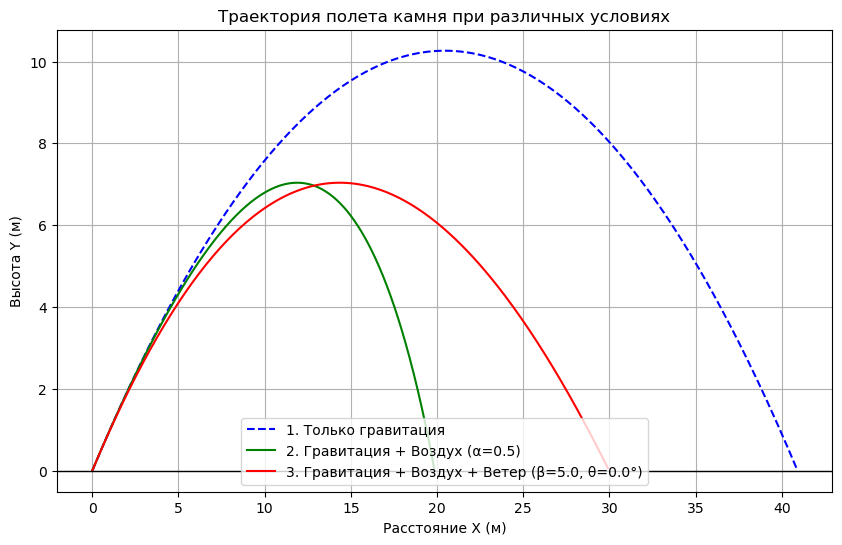

In [4]:
X1, Y1 = simulate_trajectory(mode=1)
X2, Y2 = simulate_trajectory(mode=2)
X3, Y3 = simulate_trajectory(mode=3)

plt.figure(figsize=(10, 6))

plt.plot(X1, Y1, label='1. Только гравитация', color='blue', linestyle='--')
plt.plot(X2, Y2, label=f'2. Гравитация + Воздух (α={alpha})', color='green')
plt.plot(X3, Y3, label=f'3. Гравитация + Воздух + Ветер (β={beta}, θ={theta_deg}°)', color='red')

plt.title('Траектория полета камня при различных условиях')
plt.xlabel('Расстояние X (м)')
plt.ylabel('Высота Y (м)')
plt.axhline(0, color='black', linewidth=1)
plt.grid(True)
plt.legend()
plt.show()